In [1]:
from footix.models.basic_poisson import PoissonModel
from footix.data_io.footballdata import ScrapFootballData
from footix.metrics import rps, incertity, zscore
import numpy as np

# Loading the dataset:

Here, we are going to play with the season 2024-2025 of French division ligue 1, using the scrapper of [football-data](www.footbal-data.co.uk).

We are also going to divide the dataset in two parts. One for training the model and one for benchmarking its performances

In [17]:
dataset = ScrapFootballData(competition="FRA Ligue 1", season="2024-2025", path ="./data", force_reload=True).get_fixtures()

In [18]:
dataset.head()

,div,date,time,home_team,away_team,fthg,ftag,ftr,hthg,htag,...,b365_caha,pcahh,pcaha,max_cahh,max_caha,avg_cahh,avg_caha,bfecahh,bfecaha,match_id
0,F1,2024-08-16,19:45,Le Havre,Paris SG,1,4,A,0,1,...,2.00,1.95,1.97,1.95,2.02,1.89,1.95,1.95,2.02,Le Havre - Paris SG - 2024-08-16
1,F1,2024-08-17,16:00,Brest,Marseille,1,5,A,1,3,...,2.04,1.91,2.02,1.91,2.08,1.85,2.01,1.90,2.09,Brest - Marseille - 2024-08-17
2,F1,2024-08-17,18:00,Reims,Lille,0,2,A,0,1,...,1.70,2.14,1.81,2.14,1.85,2.07,1.80,2.13,1.86,Reims - Lille - 2024-08-17
3,F1,2024-08-17,20:00,Monaco,St Etienne,1,0,H,1,0,...,1.93,2.00,1.93,2.00,2.01,1.95,1.91,1.95,2.00,Monaco - St Etienne - 2024-08-17
4,F1,2024-08-18,14:00,Auxerre,Nice,2,1,H,1,1,...,2.11,1.82,2.13,1.83,2.17,1.77,2.10,1.84,2.16,Auxerre - Nice - 2024-08-18


In [19]:
train_dataset = dataset.iloc[:-27]
test_dataset = dataset.iloc[-27:-18]

# Initialization of the model and fitting


In [20]:
model = PoissonModel(n_teams=18, n_goals=20)

In [21]:
model.fit(X_train=train_dataset)

# Let's compute some metrics

In [22]:
rps_list = []
incertity_list = []
zscore_list = []

def _helper_result(result_str: str)-> int:
    if result_str=="H":
        return 0
    if result_str=="D":
        return 1
    return 2

for idx, row in test_dataset.iterrows():
    probability = model.predict(home_team=row["home_team"], away_team=row["away_team"]).return_probas()
    outcome_idx = _helper_result(row["ftr"])
    rps_list.append(rps(probas=probability, outcome_idx=outcome_idx))
    zscore_list.append(zscore(probas=probability,rps_observed=rps_list[-1]))
    incertity_list.append(incertity(probas=probability, outcome_idx=outcome_idx))

In [23]:
print(f"Incertity metric : {np.mean(incertity_list)} +/- {np.std(incertity_list)}")
print(f"RPS metric : {np.mean(rps_list)} +/- {np.std(rps_list)}")
print(f"Z-score metric : {np.mean(zscore_list)} +/- {np.std(zscore_list)}")

Incertity metric : 1.0297298141887115 +/- 0.6141864747266377
RPS metric : 0.2798393781138697 +/- 0.22080522746118797
Z-score metric : 0.3263452950099379 +/- 0.7971838731540088


# Game focus

In [30]:
goal_matrix_object = model.predict(home_team="St Etienne", away_team="Monaco")

In [38]:
probability = goal_matrix_object.return_probas()
print("St Etienne - Monaco outcome probabilities")
print(f"Probability of home victory : {100*probability.proba_home:.2f} %")
print(f"Probability of a draw : {100*probability.proba_draw:.2f}")
print(f"Probability of away victory : {100*probability.proba_away:.2f}")

St Etienne - Monaco outcome probabilities
Probability of home victory : 14.19 %
Probability of a draw : 19.16
Probability of away victory : 66.66


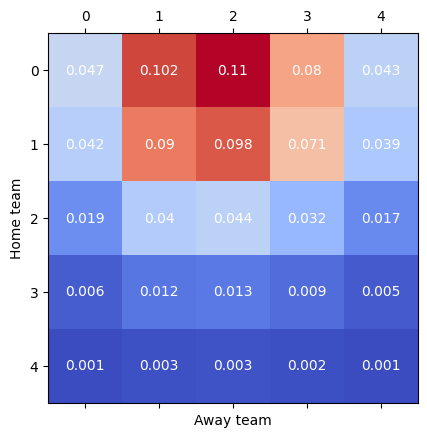

In [32]:
goal_matrix_object.visualize();

In [33]:
goal_matrix_object.get_probable_score()

(0, 2)

# True result

In [35]:
print(test_dataset[test_dataset["home_team"]=="St Etienne"]["ftr"])

282    A
Name: ftr, dtype: object


In [37]:
st_etienne_score = test_dataset.loc[
    test_dataset["home_team"] == "St Etienne", ["fthg", "ftag"]
].iloc[0]

print(f"({st_etienne_score['fthg']}-{st_etienne_score['ftag']})")

(1-3)
